In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**LOAD DATA**

Tahap awal integrasi data melibatkan pemuatan dataset pelatihan dan pengujian. Fokus utama pada fase ini adalah identifikasi integritas data melalui pemeriksaan missing values, analisis statistik kemiringan distribusi (skewness), dan pemetaan interaksi antar fitur menggunakan matriks korelasi.

In [25]:
train_df = pd.read_csv('data_training.csv')
test_df = pd.read_csv('data_testing.csv')

# Pengecekan Missing Value pada kedua dataset
print("\nMissing Values (Training):", train_df.isnull().sum().sum())
print("Missing Values (Testing):", test_df.isnull().sum().sum())

# Visualisasi Data Teratas
print("\nHead Data Training:")
display(train_df.head())


Missing Values (Training): 0
Missing Values (Testing): 0

Head Data Training:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Skewness Fitur Kimiawi:
 fixed acidity           0.714432
volatile acidity        0.392693
citric acid             0.366726
residual sugar          0.898090
chlorides               0.429967
free sulfur dioxide     0.874175
total sulfur dioxide    0.976362
density                 0.039149
pH                      0.024747
sulphates               0.799535
alcohol                 0.773037
dtype: float64


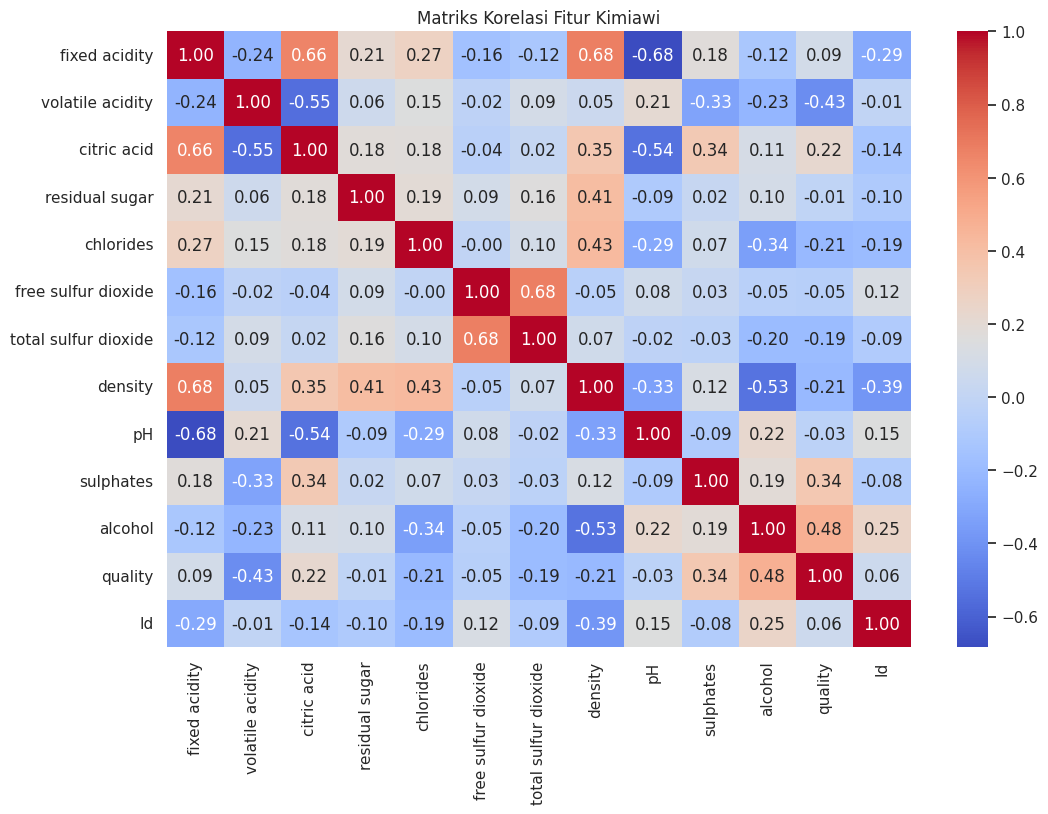

In [22]:
# Cek Skewness Fitur
print("Skewness Fitur Kimiawi:\n", train_df.drop(['Id', 'quality'], axis=1).skew())

# Visualisasi Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriks Korelasi Fitur Kimiawi")
plt.show()

**Prepocessing**

Prosedur pembersihan data difokuskan pada mitigasi dampak pencilan (outliers) yang dapat mendistorsi estimasi parameter model.diterapkan prinsip Data Splitting (The Golden Rule) untuk mengisolasi data uji guna mencegah kebocoran informasi (data leakage).Proses dilanjutkan dengan Normalisasi & Power Transformation menggunakan teknik Yeo-Johnson dan Standard Scaling untuk menyelaraskan magnitudo serta memperbaiki fitur dengan distribusi non-normal. Sebagai langkah final dalam preprocessing, diimplementasikan Handling Class Imbalance melalui Synthetic Minority Over-sampling Technique (SMOTE) secara eksklusif pada set pelatihan. Integrasi rangkaian prosedur ini dirancang untuk menciptakan batas keputusan (decision boundary) yang robust, meningkatkan konvergensi model, dan memastikan generalisasi yang stabil terhadap data baru (unseen data).

In [28]:
# Memisahkan Fitur dan Target
X = train_df.drop(['Id', 'quality'], axis=1)
y = train_df['quality'].astype(int) # Memastikan target adalah integer untuk klasifikasi
X_test = test_df.drop(['Id'], axis=1)

# Manajemen Outlier pada Fitur (Training & Testing)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
X_cleaned = X.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR, axis=1)
X_test_cleaned = X_test.clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR, axis=1)

#data splitting
X_train, X_val, y_train, y_val = train_test_split(X_cleaned, y, test_size=0.2, random_state=42, stratify=y)

In [31]:
# Transformasi untuk menangani skewness
pt = PowerTransformer(method='yeo-johnson')
X_train_pt = pt.fit_transform(X_train)
X_val_pt = pt.transform(X_val)
X_test_final_pt = pt.transform(X_test_cleaned)

# Normalisasi Skala
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pt)
X_val_scaled = scaler.transform(X_val_pt)
X_test_final_scaled = scaler.transform(X_test_final_pt)

In [47]:
# Pengecekan dan Penanganan Imbalance dengan SMOTE
print("Distribusi Kelas Sebelum SMOTE:\n", y.value_counts().sort_index())

# Mengurus data imbalance hanya pada training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Distribusi kelas setelah SMOTE:\n", pd.Series(y_resampled).value_counts())

Distribusi Kelas Sebelum SMOTE:
 quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64
Distribusi kelas setelah SMOTE:
 quality
5    362
7    362
6    362
4    362
8    362
3    362
Name: count, dtype: int64


**Ensemble Modeling & DIagnostic Evaluation**

Arsitektur prediktif dibangun menggunakan pendekatan Hybrid Ensemble (Voting Classifier) yang mengintegrasikan kekuatan Random Forest dan XGBoost. Evaluasi performa dilakukan secara komprehensif menggunakan Confusion Matrix untuk membedah akurasi per kelas, serta Classification Report untuk mengukur presisi dan recall. Pendekatan ini bertujuan untuk mengeksploitasi karakteristik unik dari masing-masing algoritma dasar dalam menangani data tabular.

Accuracy Score: 0.9244

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00         1
           4       0.83      1.00      0.91         5
           5       0.97      0.90      0.94        73
           6       0.93      0.93      0.93        68
           7       0.81      1.00      0.90        22
           8       1.00      0.67      0.80         3

    accuracy                           0.92       172
   macro avg       0.92      0.92      0.91       172
weighted avg       0.93      0.92      0.92       172



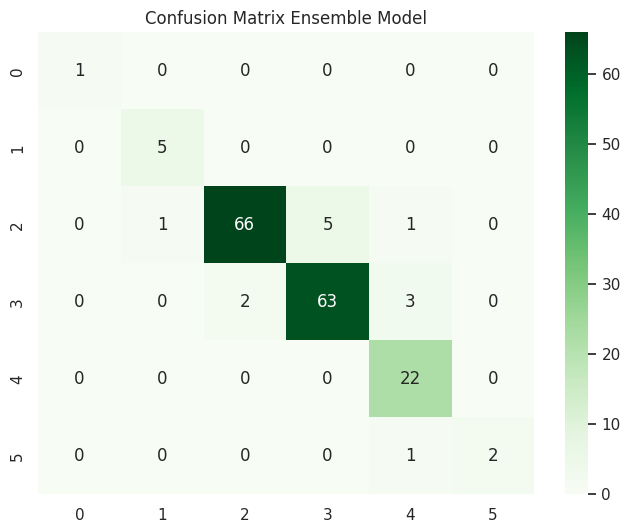

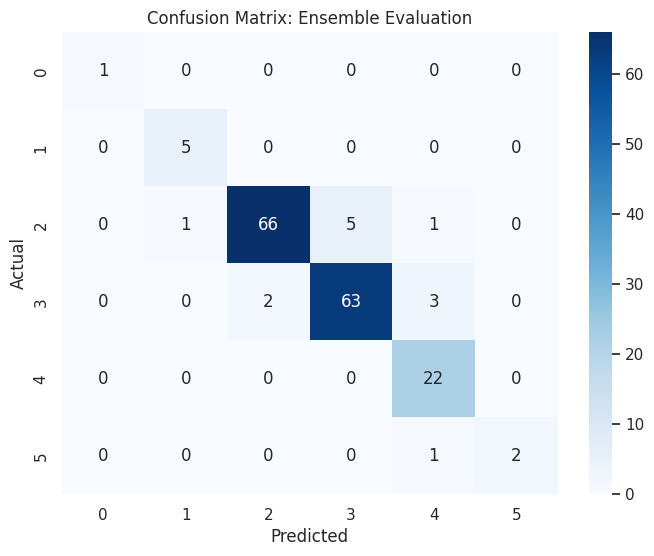

              precision    recall  f1-score   support

           3       1.00      1.00      1.00         1
           4       0.83      1.00      0.91         5
           5       0.97      0.90      0.94        73
           6       0.93      0.93      0.93        68
           7       0.81      1.00      0.90        22
           8       1.00      0.67      0.80         3

    accuracy                           0.92       172
   macro avg       0.92      0.92      0.91       172
weighted avg       0.93      0.92      0.92       172



In [40]:
# inisiasi Model Ensemble
rf = RandomForestClassifier(n_estimators=100, random_state=42)
xgb = XGBClassifier(n_estimators=100, random_state=42)
ensemble = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb)], voting='soft')

# Training
ensemble.fit(X_resampled, y_resampled)
y_pred = ensemble.predict(X_val_scaled)

# Output Evaluasi
print(f"Accuracy Score: {accuracy_score(y_val, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix Ensemble Model")
plt.show()

# Evaluasi dengan Confusion Matrix
y_pred = ensemble.predict(X_val_scaled)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Ensemble Evaluation")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_val, y_pred))

**Model Stability & Feature Importance Analysis**

Validasi reliabilitas model dilakukan melalui mekanisme 5-Fold Cross-Validation untuk mengukur konsistensi performa di berbagai partisi data. Selain itu, dilakukan ekstraksi skor Feature Importance untuk memberikan interpretasi kausalitas terhadap variabel kimiawi yang paling dominan. Analisis ini memberikan transparansi terhadap mekanisme internal model dan memastikan stabilitas prediksi dalam berbagai skenario distribusi data.

Accuracy Score pada Validation Set: 0.9244


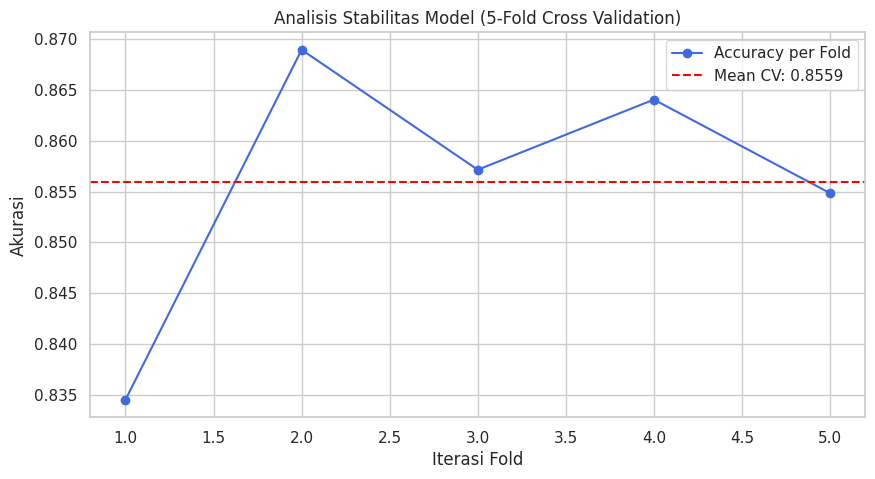

Rata-rata Akurasi Cross-Validation: 0.8559
Standar Deviasi (Variabel Stabilitas): 0.0118


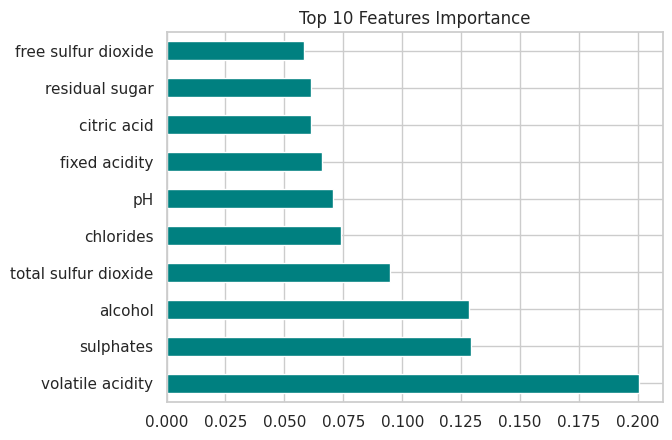

In [46]:
val_accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy Score pada Validation Set: {val_accuracy:.4f}")

# Stability Check (Cross-Validation)
cv_scores = cross_val_score(ensemble, X_resampled, y_resampled, cv=5)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', color='royalblue', label='Accuracy per Fold')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean CV: {cv_scores.mean():.4f}')
plt.title("Analisis Stabilitas Model (5-Fold Cross Validation)")
plt.xlabel("Iterasi Fold")
plt.ylabel("Akurasi")
plt.legend()
plt.grid(True)
plt.show()

print(f"Rata-rata Akurasi Cross-Validation: {cv_scores.mean():.4f}")
print(f"Standar Deviasi (Variabel Stabilitas): {cv_scores.std():.4f}")

# Feature Importance Interpretation
y_resampled_mapped = pd.Series(y_resampled).map(label_map) # Map y_resampled to 0-indexed labels
xgb.fit(X_resampled, y_resampled_mapped)
feat_importances = pd.Series(xgb.feature_importances_, index=X_cleaned.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Features Importance")
plt.show()

**Final Prediction & Output Serialization**

In [52]:
# Prediksi Data Testing
final_preds = ensemble.predict(X_test_final_scaled)

# Export File
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'quality': final_preds
})

submission.to_csv('hasil_prediksi_final.csv', index=False)
print('hasil_prediksi_final.csv')

hasil_prediksi_final.csv
